In [1]:
import cv2
import pytesseract
import matplotlib.pyplot as plt
import numpy as np
import re
import glob

# Single image:

In [ ]:
path = "/home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240815233312_.jpg"

In [ ]:
# Load the image
image = cv2.imread(path)

# Define the top-left corner and the size of the rectangle
x = 10
y = 130
w = 100
h = 400

# Select the region
square_region = image[y:y+h, x:x+w]

#plot the region with matplotlib
plt.imshow(cv2.cvtColor(square_region, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
# Preprocess the image (convert to grayscale and apply thresholding)
gray = cv2.cvtColor(square_region, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

# Use Tesseract to do OCR on the image
custom_config = r'--oem 3 --psm 6'
text = pytesseract.image_to_string(thresh, config=custom_config)

print("Detected text:", text)
print("max value:", text[:4])
print("min value:", text[7:])

# Prova:

In [2]:
def process_image (image):
    # Preprocess the image (convert to grayscale and apply thresholding)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

    # Use Tesseract to do OCR on the image
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(thresh, config=custom_config)
    return thresh, text


def process_region(region):
    # Preprocess the image (convert to grayscale and apply thresholding)
    thresh, text = process_image(region)
    numbers = re.findall(r"\d+\.?\d*", text)
    return numbers

In [10]:
def all_images (image_paths):

    # Iterate through each image in the folder
    for path in image_paths:
        print(f"Processing: {path}")

        image = cv2.imread(path)
        if image is None:
            print(f"Error loading image: {path}")
            continue  
        if image.shape[1] > image.shape[0]: # image is landscape
            u = [10, 130, 80, 50]
            l = [10, 385, 80, 50]
        else:
            u = [10, 130, 100, 50]
            l = [10, 450, 80, 50]
        
        ux, uy, uw, uh = u  # Upper region
        lx, ly, lw, lh = l  # Lower region
        
        # image[y:y+h, x:x+w]
        square_region_upper = image[uy:uy+uh, ux:ux+uw]
        square_region_lower = image[ly:ly+lh, lx:lx+lw]

        plt.figure(figsize=(3, 1))  # Adjust size for better visualization
        
        plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
        plt.imshow(cv2.cvtColor(square_region_upper, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
        plt.imshow(cv2.cvtColor(square_region_lower, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        numbers = process_region(square_region_upper)
        numbers2 = process_region(square_region_lower)
        
        if len(numbers) > 0 and len(numbers2) > 0:
            print(f"   Max Value: {max(numbers)}           |       Min Value: {min(numbers2)}")
        elif numbers == []:
            print(f"Min Value: {min(numbers2)}")
            print("No max value detected")
            continue
        elif numbers2 == []:
            print(f"Max Value: {max(numbers)}")
            print("No min value detected")
            continue

        print("-" * 100)  # Separator for readability


## Horizontal:

In [11]:
folder_path_horizontal = "/home/martina/codi2/50_02.12.24-03.12.24/*.jpeg"

# Get a list of all image files in the folder
image_paths_horizontal = sorted(glob.glob(folder_path_horizontal))

print(len(image_paths_horizontal)) 


500


Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202214203.jpeg


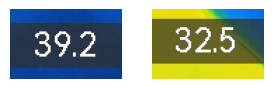

   Max Value: 39.2           |       Min Value: 32.5
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202214304.jpeg


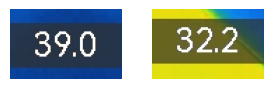

   Max Value: 39.0           |       Min Value: 32.2
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202214405.jpeg


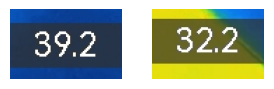

   Max Value: 39.2           |       Min Value: 32.2
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202214507.jpeg


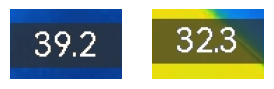

   Max Value: 39.2           |       Min Value: 323
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202214608.jpeg


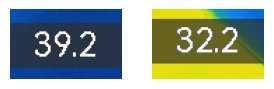

   Max Value: 39.2           |       Min Value: 32.2
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202214709.jpeg


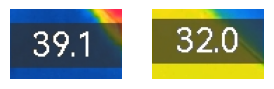

   Max Value: 39.1           |       Min Value: 32.0
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202214811.jpeg


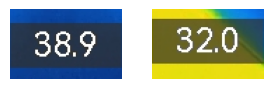

   Max Value: 38.9           |       Min Value: 32.0
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202214912.jpeg


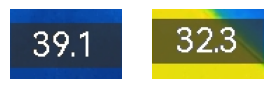

   Max Value: 39.1           |       Min Value: 323
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215013.jpeg


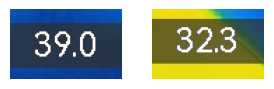

   Max Value: 39.0           |       Min Value: 323
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215114.jpeg


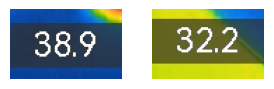

   Max Value: 38.9           |       Min Value: 32.2
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215215.jpeg


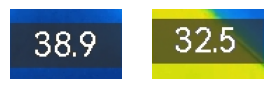

   Max Value: 38.9           |       Min Value: 32.5
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215317.jpeg


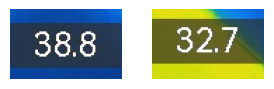

   Max Value: 38.8           |       Min Value: 32.7
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215418.jpeg


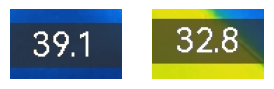

   Max Value: 39.1           |       Min Value: 32.8
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215519.jpeg


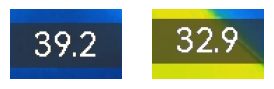

   Max Value: 39.2           |       Min Value: 32.9
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215620.jpeg


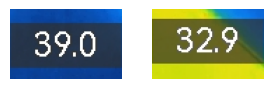

   Max Value: 39.0           |       Min Value: 32.9
----------------------------------------------------------------------------------------------------


In [12]:
all_images(image_paths_horizontal[35:50])

## Vertical:


In [13]:
folder_path_vertical = "/home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/*.jpg"

# Get a list of all image files in the folder
image_paths_vertical = sorted(glob.glob(folder_path_vertical))

print(len(image_paths_vertical)) 


7


Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240815233312_.jpg


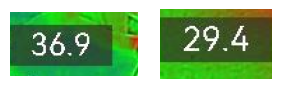

   Max Value: 36.9           |       Min Value: 29.4
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816005549_.jpg


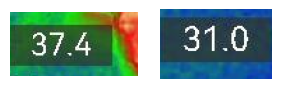

   Max Value: 3745           |       Min Value: 31.0
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816011016_.jpg


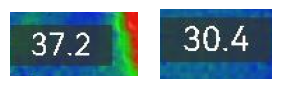

   Max Value: 37.2           |       Min Value: 30.4
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816030018_.jpg


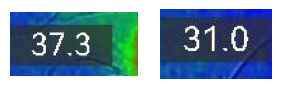

   Max Value: 37.3           |       Min Value: 31.0
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816050859_.jpg


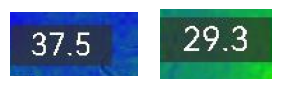

   Max Value: 37.5           |       Min Value: 29.3
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816065935_.jpg


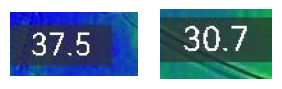

   Max Value: 37.5           |       Min Value: 30.7
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816074705_.jpg


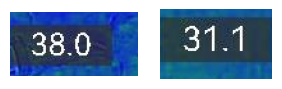

   Max Value: 38.0           |       Min Value: 31.1
----------------------------------------------------------------------------------------------------


In [14]:
all_images(image_paths_vertical[:])